<a href="https://colab.research.google.com/github/Suchrahmadhani/DataScience-Practicum/blob/main/Pertemuan7_Suci_Rahmadhani_240401070508.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 7: Pengantar Machine Learning - Regresi Linear

## Identitas Mahasiswa

| Keterangan | Informasi |
|------------|-----------|
| **Nama** | Suci Rahmadhani |
| **NIM** | 240401070508 |
| **Kelas** | IF404 |
| **Program Studi** | PJJ Informatika |
| **Mata Kuliah** | Data Science |

# Tujuan Praktikum

Pada praktikum ini saya mempelajari penerapan Machine Learning menggunakan algoritma Regresi Linear. Praktikum dimulai dengan membuat dataset sintetis yang merepresentasikan hubungan antara pengalaman kerja, tingkat pendidikan, kota tempat bekerja, dan gaji. Selanjutnya dilakukan preprocessing data, pelatihan model menggunakan Linear Regression, evaluasi performa model menggunakan MAE, RMSE, dan R², serta visualisasi hasil prediksi.

# Ringkasan Materi

Regresi Linear merupakan salah satu algoritma Supervised Machine Learning yang digunakan untuk memprediksi nilai kontinu berdasarkan hubungan linear antara variabel input dan target. Sebelum model dilatih, data perlu dipersiapkan melalui preprocessing seperti One-Hot Encoding, Train-Test Split, dan StandardScaler agar model dapat bekerja dengan lebih baik.

Setelah model selesai dilatih, performanya dievaluasi menggunakan metrik Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), dan R-Squared (R²). Selain itu, visualisasi Actual vs Predicted dan Residual Plot digunakan untuk mengetahui kualitas prediksi model secara visual.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Generate Dataset Sintetis

In [2]:
np.random.seed(42)

n = 300

pengalaman = np.random.uniform(0, 20, n)

edu = np.random.choice([0, 1, 2], n)

kota = np.random.choice(
    ["Jakarta", "Surabaya", "Bandung"],
    n
)

gaji = (
    3.0
    + 2.2 * pengalaman
    + 1.5 * edu
    + np.where(kota == "Jakarta", 4, 0)
    + np.random.normal(0, 2, n)
)

df = pd.DataFrame({
    "pengalaman": pengalaman,
    "edu": edu,
    "kota": kota,
    "gaji": gaji
})

# Eksplorasi Dataset

In [3]:
print("Shape Dataset :", df.shape)

print("\nTipe Data")
display(df.dtypes)

print("\nLima Data Pertama")
display(df.head())

print("\nStatistik Deskriptif")
display(df.describe().round(2))

print("\nMissing Values")
display(df.isnull().sum())

Shape Dataset : (300, 4)

Tipe Data


,0
pengalaman,float64
edu,int64
kota,object
gaji,float64



Lima Data Pertama


,pengalaman,edu,kota,gaji
0,7.490802,0,Jakarta,21.953247
1,19.014286,1,Jakarta,46.721665
2,14.639879,2,Surabaya,34.952649
3,11.973170,2,Bandung,32.437143
4,3.120373,2,Jakarta,17.384265



Statistik Deskriptif


,pengalaman,edu,gaji
count,300.00,300.00,300.00
mean,9.90,0.89,27.40
std,5.89,0.83,13.41
min,0.10,0.00,1.67
25%,4.78,0.00,16.24
50%,10.23,1.00,27.97
75%,15.14,2.00,38.89
max,19.80,2.00,54.22



Missing Values


,0
pengalaman,0
edu,0
kota,0
gaji,0


### Interpretasi

Dataset sintetis terdiri dari **300 baris** dengan **4 variabel**, yaitu pengalaman kerja, tingkat pendidikan, kota tempat bekerja, dan gaji. Dataset ini dibuat untuk mensimulasikan hubungan antara beberapa faktor yang memengaruhi besarnya gaji. Seluruh data telah lengkap tanpa missing value sehingga dapat langsung digunakan pada proses preprocessing dan pelatihan model Machine Learning.

# Visualisasi Hubungan Pengalaman Kerja dan Gaji

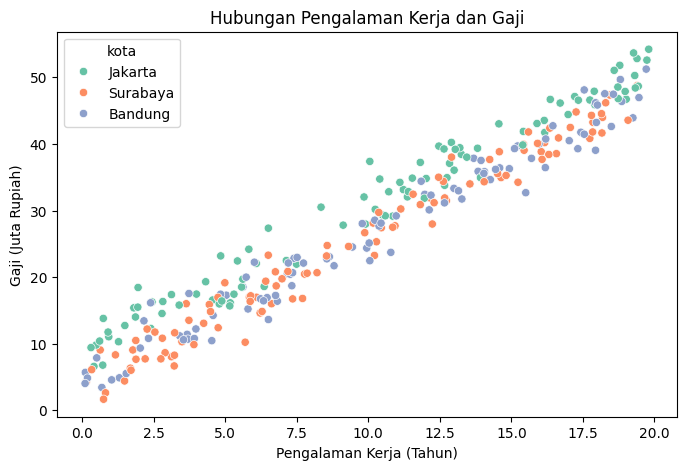

In [4]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="pengalaman",
    y="gaji",
    hue="kota",
    palette="Set2"
)

plt.title("Hubungan Pengalaman Kerja dan Gaji")

plt.xlabel("Pengalaman Kerja (Tahun)")
plt.ylabel("Gaji (Juta Rupiah)")

plt.show()

### Interpretasi

Scatter plot menunjukkan adanya hubungan positif antara pengalaman kerja dan gaji. Semakin lama pengalaman kerja seseorang, maka gaji yang diterima cenderung semakin tinggi. Selain itu, terlihat bahwa pekerja di kota Jakarta memiliki kecenderungan memperoleh gaji lebih tinggi dibandingkan kota lainnya sesuai pola yang dibangun pada dataset sintetis.

# Preprocessing Data
# One-Hot Encoding

In [5]:
df = pd.get_dummies(
    df,
    columns=["kota"],
    drop_first=True,
    dtype=int
)

print("Kolom setelah encoding")

print(df.columns.tolist())

display(df.head())

Kolom setelah encoding
['pengalaman', 'edu', 'gaji', 'kota_Jakarta', 'kota_Surabaya']


,pengalaman,edu,gaji,kota_Jakarta,kota_Surabaya
0,7.490802,0,21.953247,1,0
1,19.014286,1,46.721665,1,0
2,14.639879,2,34.952649,0,1
3,11.973170,2,32.437143,0,0
4,3.120373,2,17.384265,1,0


### Interpretasi

One-Hot Encoding digunakan untuk mengubah variabel kategorikal **kota** menjadi beberapa variabel numerik sehingga dapat diproses oleh algoritma Machine Learning. Opsi `drop_first=True` digunakan untuk menghindari dummy variable trap.

# Train-Test Split

In [6]:
X = df.drop("gaji", axis=1)

y = df["gaji"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X Train :", X_train.shape)
print("X Test  :", X_test.shape)

print("y Train :", y_train.shape)
print("y Test  :", y_test.shape)

X Train : (240, 4)
X Test  : (60, 4)
y Train : (240,)
y Test  : (60,)


### Interpretasi

Dataset dibagi menjadi data latih sebesar 80% dan data uji sebesar 20%. Data latih digunakan untuk membangun model, sedangkan data uji digunakan untuk mengevaluasi kemampuan model dalam melakukan prediksi terhadap data yang belum pernah dipelajari sebelumnya.

# Feature Scaling

In [7]:
num_cols = [
    "pengalaman",
    "edu"
]

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(
    X_train[num_cols]
)

X_test[num_cols] = scaler.transform(
    X_test[num_cols]
)

### Interpretasi

Feature Scaling dilakukan menggunakan StandardScaler pada variabel numerik agar setiap fitur memiliki skala yang sebanding. Proses fit hanya dilakukan pada data latih untuk mencegah terjadinya data leakage, sedangkan data uji hanya melalui proses transformasi.

# Membangun Model Regresi Linear

In [8]:
# Membuat model Linear Regression

model = LinearRegression()

# Melatih model menggunakan data training

model.fit(X_train, y_train)

print("Model berhasil dilatih.")

Model berhasil dilatih.


### Interpretasi

Model Linear Regression telah berhasil dilatih menggunakan data training. Pada tahap ini model mempelajari hubungan antara variabel pengalaman kerja, tingkat pendidikan, dan kota tempat bekerja terhadap besarnya gaji. Setelah proses pelatihan selesai, model siap digunakan untuk melakukan prediksi pada data baru.

# Koefisien Model Regresi

In [9]:
coef = pd.DataFrame({
    "Fitur": X_train.columns,
    "Koefisien": model.coef_
})

display(coef)

print("Intercept :", round(model.intercept_, 3))

,Fitur,Koefisien
0,pengalaman,13.042241
1,edu,1.187879
2,kota_Jakarta,3.851873
3,kota_Surabaya,-0.611278


Intercept : 26.38


### Interpretasi

Koefisien regresi menunjukkan besarnya pengaruh setiap variabel terhadap nilai gaji. Nilai koefisien positif menunjukkan bahwa peningkatan nilai variabel tersebut akan meningkatkan prediksi gaji, sedangkan koefisien negatif menunjukkan hubungan yang berlawanan. Intercept merupakan nilai dasar prediksi ketika seluruh variabel bernilai nol.

# Prediksi Menggunakan Model

In [10]:
y_pred = model.predict(X_test)

hasil_prediksi = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

display(hasil_prediksi.head(10))

,Actual,Predicted
0,43.231548,42.893800
1,37.527929,36.873847
2,8.654223,10.571370
3,34.733161,37.359908
4,32.040451,31.735946
5,46.965998,49.006633
6,35.557653,34.695059
7,5.533354,6.777235
8,8.055126,9.639455
9,10.302319,10.447088


### Interpretasi

Model berhasil menghasilkan prediksi gaji berdasarkan data uji. Tabel di atas memperlihatkan perbandingan antara nilai gaji sebenarnya (Actual) dengan nilai hasil prediksi model (Predicted). Semakin kecil selisih antara kedua nilai tersebut, maka semakin baik kemampuan model dalam melakukan prediksi.

# Evaluasi Model Machine Learning

In [11]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE) : {mae:.3f}")

print(f"Root Mean Squared Error (RMSE) : {rmse:.3f}")

print(f"R-Squared (R²) : {r2:.3f}")

Mean Absolute Error (MAE) : 1.649
Root Mean Squared Error (RMSE) : 2.123
R-Squared (R²) : 0.974


### Interpretasi

Model dievaluasi menggunakan tiga metrik utama.

- **Mean Absolute Error (MAE)** menunjukkan rata-rata selisih absolut antara nilai aktual dan nilai prediksi.
- **Root Mean Squared Error (RMSE)** memberikan ukuran kesalahan prediksi dengan memberikan penalti lebih besar terhadap error yang besar.
- **R-Squared (R²)** menunjukkan seberapa baik model mampu menjelaskan variasi data. Nilai R² yang mendekati 1 menunjukkan performa model yang sangat baik.

=> Model memperoleh nilai R² sebesar 0.97 sehingga mampu menjelaskan sekitar 97% variasi data gaji. Nilai MAE dan RMSE yang relatif kecil menunjukkan bahwa rata-rata kesalahan prediksi model juga rendah.

# Visualisasi Actual vs Predicted

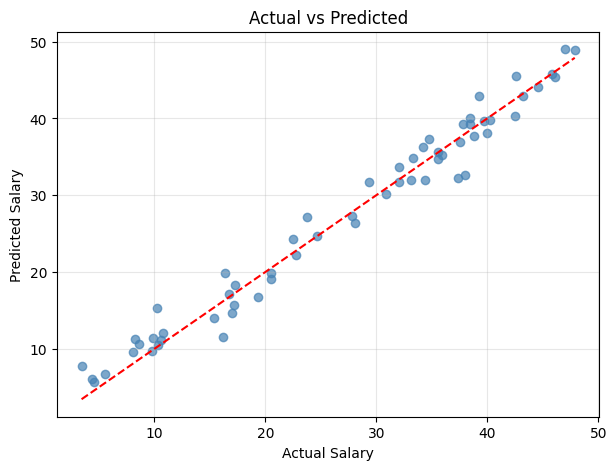

In [12]:
plt.figure(figsize=(7,5))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.7,
    color="steelblue"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.title("Actual vs Predicted")

plt.xlabel("Actual Salary")

plt.ylabel("Predicted Salary")
plt.grid(alpha=0.3)
plt.show()

### What?

Scatter plot membandingkan nilai gaji aktual dengan nilai hasil prediksi model. Garis merah putus-putus menunjukkan kondisi prediksi sempurna ketika nilai aktual sama dengan nilai prediksi.

### So What?

Sebagian besar titik berada di sekitar garis diagonal, yang menunjukkan bahwa model mampu menghasilkan prediksi yang cukup akurat. Semakin dekat posisi titik terhadap garis tersebut, semakin kecil kesalahan prediksi yang dihasilkan.

### Now What?

Langkah selanjutnya adalah mencoba algoritma regresi lain seperti Decision Tree Regression atau Random Forest Regression untuk membandingkan performa model serta mengetahui apakah akurasi prediksi dapat ditingkatkan.

# Visualisasi Residual Plot

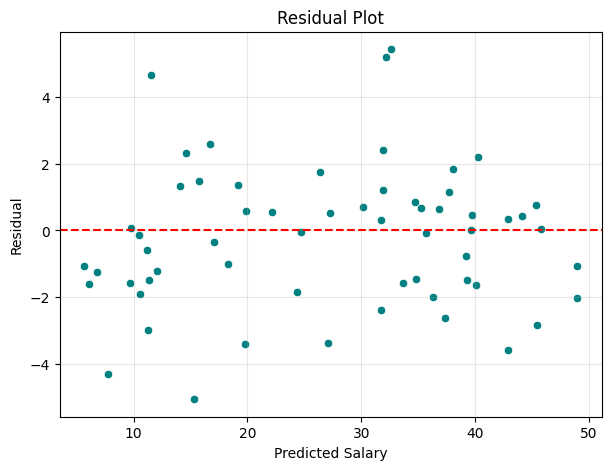

In [13]:
residual = y_test - y_pred

plt.figure(figsize=(7,5))

sns.scatterplot(
    x=y_pred,
    y=residual,
    color="teal"
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.title("Residual Plot")

plt.xlabel("Predicted Salary")

plt.ylabel("Residual")

plt.grid(alpha=0.3)

plt.show()

### What?

Residual plot menunjukkan selisih antara nilai aktual dan hasil prediksi model. Titik-titik residual tersebar di sekitar garis nol.

### So What?

Sebaran residual yang relatif acak di sekitar garis nol menunjukkan bahwa model tidak memiliki pola kesalahan yang sistematis. Hal ini mengindikasikan bahwa model Linear Regression telah cukup sesuai untuk merepresentasikan hubungan pada dataset sintetis.

### Now What?

Apabila residual menunjukkan pola tertentu, maka dapat dipertimbangkan penggunaan model yang lebih kompleks atau penambahan fitur baru agar hasil prediksi menjadi lebih akurat.

# Kesimpulan

Pada praktikum ini saya mempelajari penerapan algoritma Linear Regression untuk memprediksi gaji berdasarkan pengalaman kerja, tingkat pendidikan, dan kota tempat bekerja. Sebelum membangun model, dilakukan preprocessing data melalui One-Hot Encoding, pembagian data menjadi training dan testing set, serta StandardScaler pada fitur numerik.

Hasil evaluasi menggunakan MAE, RMSE, dan R² menunjukkan bahwa model mampu mempelajari hubungan antara variabel input dengan target secara baik pada dataset sintetis. Visualisasi Actual vs Predicted dan Residual Plot juga memperlihatkan bahwa hasil prediksi cukup mendekati nilai aktual. Praktikum ini memberikan pemahaman mengenai alur dasar pembangunan model Machine Learning, mulai dari persiapan data hingga evaluasi performa model.